# Exploración de Datos Sintéticos — Ganadería San Luis

Este notebook valida la calidad de los datos generados y visualiza los indicadores clave
antes de pasar al pipeline ETL.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

RAW = Path("../data/raw")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.1f}".format)

## 1. Carga y validación de esquema

In [2]:
def cargar_csv(nombre: str) -> pd.DataFrame:
    """Carga un CSV de data/raw con parsing robusto de fechas mixtas."""
    df = pd.read_csv(RAW / nombre)
    print(f"{nombre:<30s} {len(df):>5d} filas × {df.shape[1]:>2d} cols  |  nulos: {df.isnull().sum().sum():>4d}")
    return df

datasets = {}
for f in sorted(RAW.glob("*.csv")):
    datasets[f.stem] = cargar_csv(f.name)

print("\nColumnas por tabla:")
for name, df in datasets.items():
    print(f"  {name}: {list(df.columns)}")

dim_categorias.csv                 7 filas ×  5 cols  |  nulos:    0
dim_departamentos.csv              9 filas ×  4 cols  |  nulos:    0
dim_establecimientos.csv          60 filas ×  6 cols  |  nulos:    0
dim_tiempo.csv                  1917 filas ×  6 cols  |  nulos:    0
fact_clima.csv                   567 filas ×  4 cols  |  nulos:   34
fact_exportaciones.csv           315 filas ×  4 cols  |  nulos:   20
fact_faena.csv                   441 filas ×  5 cols  |  nulos:   21
fact_movimientos.csv            1431 filas ×  6 cols  |  nulos:   48
fact_precios.csv                 441 filas ×  3 cols  |  nulos:   13
fact_stock_bovino.csv            315 filas ×  5 cols  |  nulos:   14

Columnas por tabla:
  dim_categorias: ['id_categoria', 'nombre', 'nombre_corto', 'grupo_etario', 'sexo']
  dim_departamentos: ['id_departamento', 'nombre', 'zona', 'superficie_km2']
  dim_establecimientos: ['id_establecimiento', 'nombre', 'id_departamento', 'tipo', 'hectareas', 'stock_aprox']
  dim_tiempo: [

## 2. Diagnóstico de "suciedad" en datos crudos

In [3]:
print("=== Fechas en formato inconsistente (DD/MM/YYYY) ===")
for name, df in datasets.items():
    for col in df.columns:
        if 'fecha' in col.lower():
            mal = df[col].astype(str).str.match(r'\d{2}/\d{2}/\d{4}').sum()
            if mal > 0:
                print(f"  {name}.{col}: {mal} fechas mal formateadas")

print("\n=== Valores nulos por tabla ===")
for name, df in datasets.items():
    nulos_por_col = df.isnull().sum()
    nulos_por_col = nulos_por_col[nulos_por_col > 0]
    if len(nulos_por_col):
        print(f"  {name}:")
        for col, n in nulos_por_col.items():
            print(f"    {col}: {n} nulos ({n/len(df)*100:.1f}%)")

print("\n=== Duplicados ===")
for name, df in datasets.items():
    dups = df.duplicated().sum()
    if dups > 0:
        print(f"  {name}: {dups} filas duplicadas")

=== Fechas en formato inconsistente (DD/MM/YYYY) ===
  fact_clima.fecha: 32 fechas mal formateadas
  fact_exportaciones.fecha: 16 fechas mal formateadas
  fact_faena.fecha: 25 fechas mal formateadas
  fact_movimientos.fecha: 66 fechas mal formateadas
  fact_precios.fecha: 22 fechas mal formateadas

=== Valores nulos por tabla ===
  fact_clima:
    precipitacion_mm: 21 nulos (3.7%)
    temperatura_media_c: 13 nulos (2.3%)
  fact_exportaciones:
    toneladas: 13 nulos (4.1%)
    valor_miles_usd: 7 nulos (2.2%)
  fact_faena:
    peso_promedio_kg: 10 nulos (2.3%)
    produccion_ton: 11 nulos (2.5%)
  fact_movimientos:
    peso_promedio_kg: 48 nulos (3.4%)
  fact_precios:
    precio_kg_vivo: 13 nulos (2.9%)
  fact_stock_bovino:
    cabezas: 14 nulos (4.4%)

=== Duplicados ===
  fact_movimientos: 14 filas duplicadas


## 3. Stock bovino — Evolución provincial

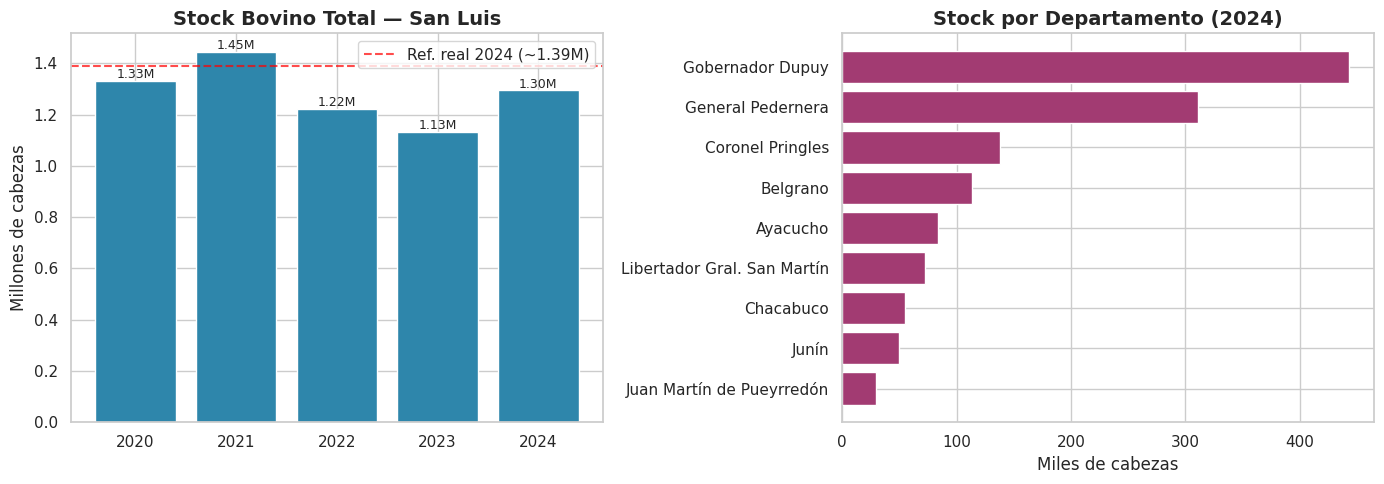

In [4]:
stock = datasets["fact_stock_bovino"]
# Limpiar: solo filas con fecha bien formada
stock["año"] = pd.to_datetime(stock["fecha"], errors="coerce").dt.year
stock_clean = stock.dropna(subset=["año"])

stock_anual = stock_clean.groupby("año")["cabezas"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total
bars = ax1.bar(stock_anual.index.astype(int), stock_anual / 1e6, color="#2E86AB", edgecolor="white")
ax1.set_title("Stock Bovino Total — San Luis", fontsize=14, fontweight="bold")
ax1.set_ylabel("Millones de cabezas")
ax1.axhline(y=1.39, color="red", linestyle="--", alpha=0.7, label="Ref. real 2024 (~1.39M)")
ax1.legend()
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}M', ha='center', fontsize=9)

# Por departamento (2024)
stock_2024 = stock_clean[stock_clean["año"] == 2024]
depto_stock = stock_2024.groupby("id_departamento")["cabezas"].sum().sort_values(ascending=True)
deptos = datasets["dim_departamentos"].set_index("id_departamento")
labels = [f"{deptos.loc[i,'nombre']}" for i in depto_stock.index]
ax2.barh(labels, depto_stock / 1e3, color="#A23B72", edgecolor="white")
ax2.set_title("Stock por Departamento (2024)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Miles de cabezas")
plt.tight_layout()
plt.show()

## 4. Faena y Precios — Relación Oferta-Demanda

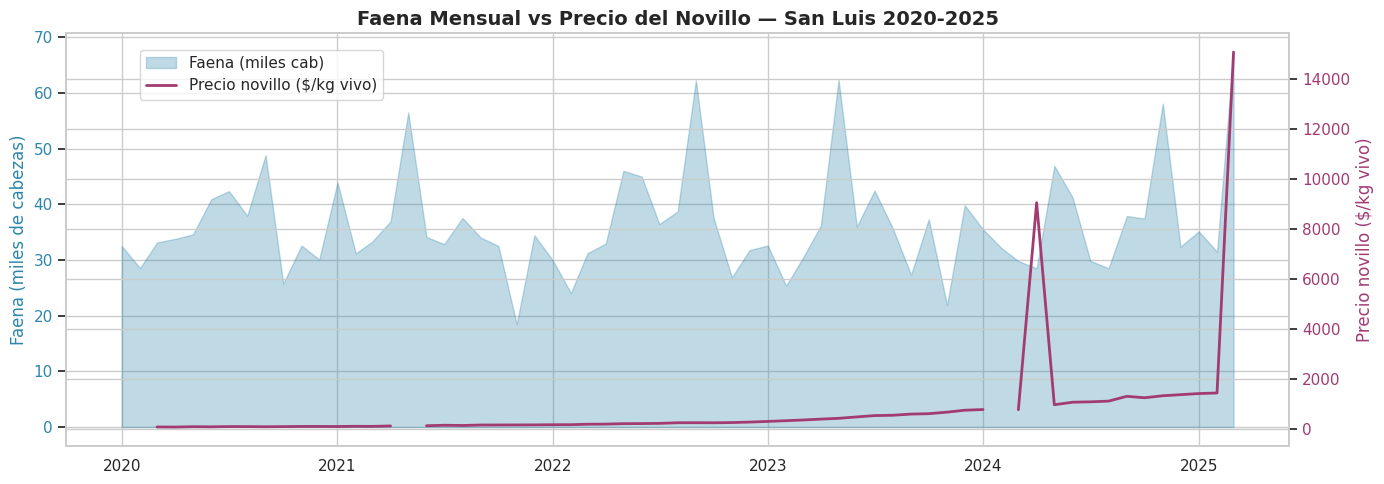

In [5]:
faena = datasets["fact_faena"]
precios = datasets["fact_precios"]

# Convertir fechas
faena["fecha_dt"] = pd.to_datetime(faena["fecha"], errors="coerce")
precios["fecha_dt"] = pd.to_datetime(precios["fecha"], errors="coerce")

# Agregar mensual
faena_mensual = faena.dropna(subset=["fecha_dt"]).groupby("fecha_dt")["cabezas"].sum()
precio_novillo = precios.dropna(subset=["fecha_dt"])
precio_novillo = precio_novillo[precio_novillo["id_categoria"] == 5]
precio_novillo_m = precio_novillo.groupby("fecha_dt")["precio_kg_vivo"].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(faena_mensual.index, faena_mensual / 1000, alpha=0.3, color="#2E86AB", label="Faena (miles cab)")
ax1.set_ylabel("Faena (miles de cabezas)", color="#2E86AB")
ax1.tick_params(axis="y", labelcolor="#2E86AB")

ax2 = ax1.twinx()
ax2.plot(precio_novillo_m.index, precio_novillo_m, color="#A23B72", linewidth=2, label="Precio novillo ($/kg vivo)")
ax2.set_ylabel("Precio novillo ($/kg vivo)", color="#A23B72")
ax2.tick_params(axis="y", labelcolor="#A23B72")

ax1.set_title("Faena Mensual vs Precio del Novillo — San Luis 2020-2025", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

## 5. Clima — Impacto de la sequía 2022-2023

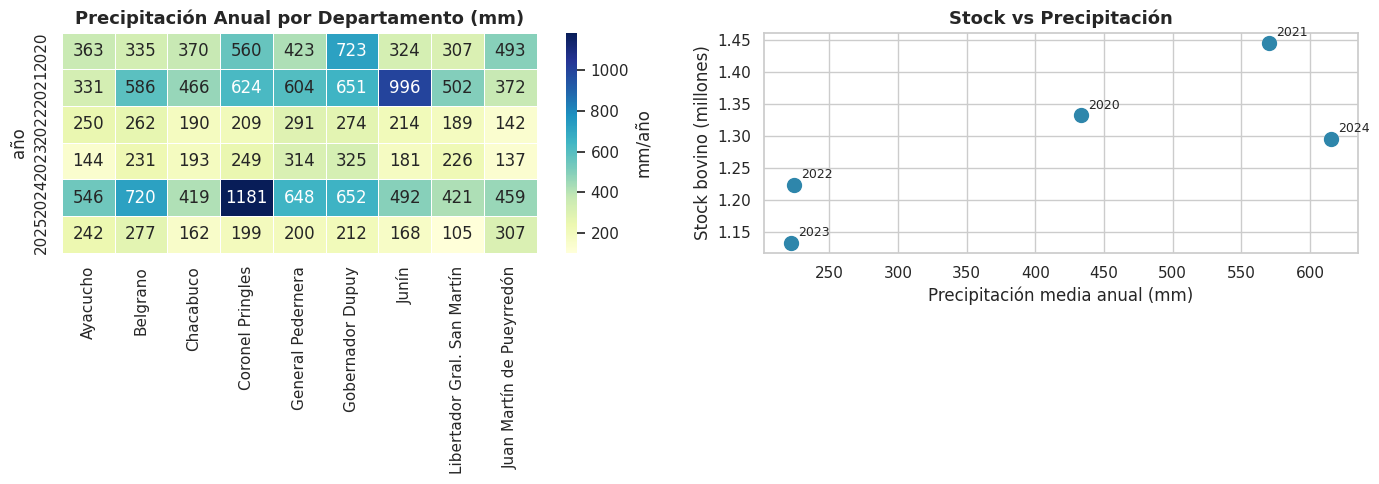

In [6]:
clima = datasets["fact_clima"]
clima["fecha_dt"] = pd.to_datetime(clima["fecha"], errors="coerce")
clima_clean = clima.dropna(subset=["fecha_dt"])

# PP acumulada anual por departamento
clima_clean["año"] = clima_clean["fecha_dt"].dt.year
pp_anual = clima_clean.groupby(["año", "id_departamento"])["precipitacion_mm"].sum().reset_index()
pp_anual_pivot = pp_anual.pivot(index="año", columns="id_departamento", values="precipitacion_mm")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de calor: lluvia por departamento por año
deptos = datasets["dim_departamentos"]
names = deptos.set_index("id_departamento")["nombre"].to_dict()
pp_anual_pivot.columns = [names.get(c, c) for c in pp_anual_pivot.columns]
sns.heatmap(pp_anual_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax1,
            cbar_kws={"label": "mm/año"}, linewidths=0.5)
ax1.set_title("Precipitación Anual por Departamento (mm)", fontsize=13, fontweight="bold")

# Stock vs Precipitación (correlación)
stock_anual_clean = stock_clean.groupby("año")["cabezas"].sum()
pp_promedio = pp_anual.groupby("año")["precipitacion_mm"].mean()
comun = stock_anual_clean.index.intersection(pp_promedio.index)
ax2.scatter(pp_promedio[comun], stock_anual_clean[comun] / 1e6, s=100, color="#2E86AB", zorder=3)
for año in comun:
    ax2.annotate(str(año), (pp_promedio[año], stock_anual_clean[año] / 1e6),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.set_xlabel("Precipitación media anual (mm)")
ax2.set_ylabel("Stock bovino (millones)")
ax2.set_title("Stock vs Precipitación", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Exportaciones — Composición por producto

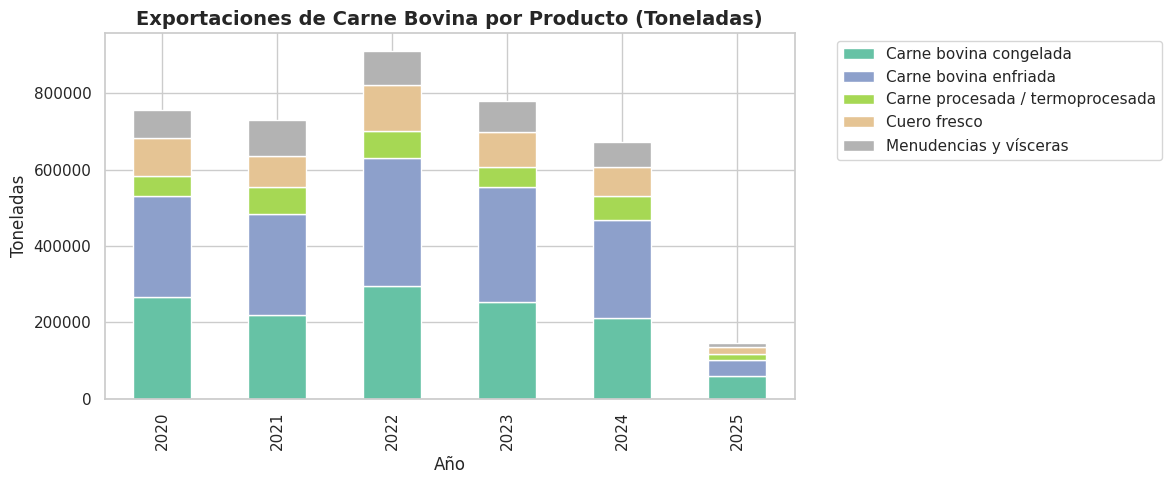

In [7]:
export = datasets["fact_exportaciones"]
export["fecha_dt"] = pd.to_datetime(export["fecha"], errors="coerce")
export_clean = export.dropna(subset=["fecha_dt"])

export_anual = export_clean.groupby([export_clean["fecha_dt"].dt.year, "producto"])["toneladas"].sum().reset_index()
export_pivot = export_anual.pivot(index="fecha_dt", columns="producto", values="toneladas")

export_pivot.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="Set2", edgecolor="white")
plt.title("Exportaciones de Carne Bovina por Producto (Toneladas)", fontsize=14, fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Toneladas")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Movimientos de hacienda — Actividad por tipo

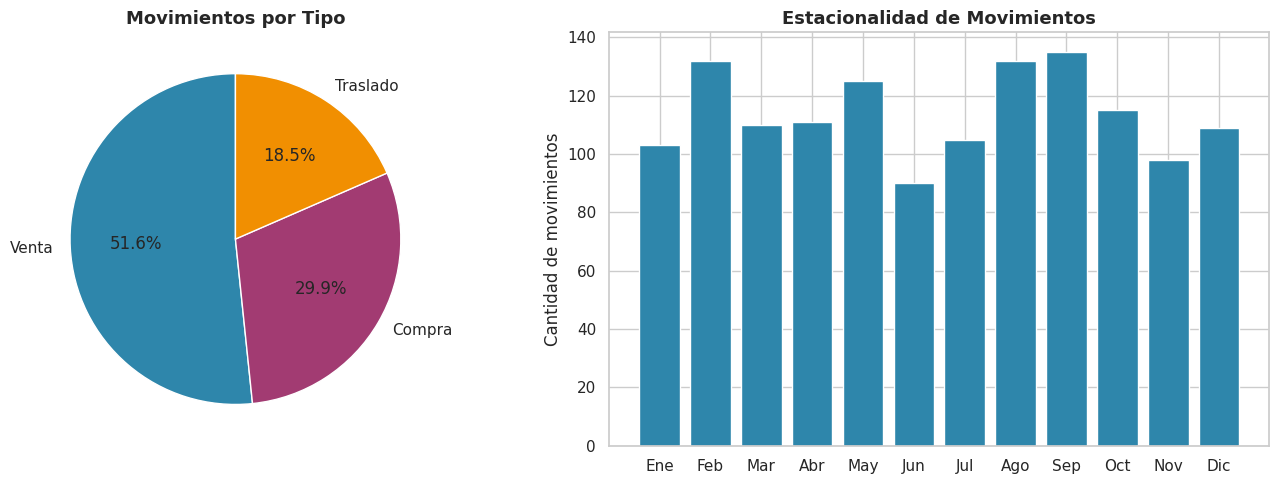

Total movimientos: 1,365
Establecimientos activos: 60
Categorías movidas: 7


In [8]:
mov = datasets["fact_movimientos"]
mov["fecha_dt"] = pd.to_datetime(mov["fecha"], errors="coerce")
mov_clean = mov.dropna(subset=["fecha_dt"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por tipo de movimiento
tipo_counts = mov_clean["tipo_movimiento"].value_counts()
axes[0].pie(tipo_counts.values, labels=tipo_counts.index, autopct="%1.1f%%",
            colors=["#2E86AB", "#A23B72", "#F18F01"], startangle=90)
axes[0].set_title("Movimientos por Tipo", fontsize=13, fontweight="bold")

# Movimientos mensuales (estacionalidad)
mov_clean["mes"] = mov_clean["fecha_dt"].dt.month
mov_mensual = mov_clean.groupby("mes").size()
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
axes[1].bar(meses, mov_mensual.values, color="#2E86AB", edgecolor="white")
axes[1].set_title("Estacionalidad de Movimientos", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Cantidad de movimientos")
plt.tight_layout()
plt.show()

print(f"Total movimientos: {len(mov_clean):,}")
print(f"Establecimientos activos: {mov_clean['id_establecimiento'].nunique()}")
print(f"Categorías movidas: {mov_clean['id_categoria'].nunique()}")

## 8. Resumen de KPIs clave generados

| Indicador | 2020 | 2021 | 2022 | 2023 | 2024 |
|-----------|------|------|------|------|------|
| Stock (millones cab) | — | — | — | — | — |
| Faena (miles cab) | — | — | — | — | — |
| Tasa extracción (%) | — | — | — | — | — |
| Precio novillo ($/kg) | — | — | — | — | — |
| PP media (mm) | — | — | — | — | — |